In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path

In [4]:
cat_path = "cats/all_stars_+0_super_granulation_RMS.csv"
cat = pd.read_csv(cat_path)
gen_planet_path="output/spawned_planets/MC10000_spawned_all_star_planets"
det_limit_path="output/detection_threshold/MC10000_spawned_all_star_planets"
det_planet_path="output/detected_planets/MC10000_spawned_all_star_planets"

In [24]:
def plot_one_star(star_name):
    gen_planets = np.load(Path(gen_planet_path) / f"{star_name}.npy")
    det_limits = np.load(Path(det_limit_path) / f"{star_name}.npy")
    det_planets = np.load(Path(det_planet_path) / f"{star_name}.npy")

    detected_ind = det_planets["detected"] == True

    plt.figure(figsize=(10, 6))
    plt.scatter(gen_planets["sma_au"], gen_planets["mass_mearth"], color='gray', alpha=0.7, label='Generated Planets', s = 20)
    plt.scatter(det_planets["sma_au"][detected_ind], det_planets["mass_mearth"][detected_ind], color='crimson', alpha=1, label='Detected Planets', s = 40)
    plt.plot(det_limits["sma_au"], det_limits["mass_limit_mearth"], color='black', label='Detection Limit')
    plt.xlabel('Period [days]', fontsize=14)
    plt.ylabel( "Planet mass [M$_\\oplus$]", fontsize=14)
    plt.tick_params(axis='both', which='major', labelsize=13)
    plt.title(f'{star_name}', fontsize=16)
    plt.legend()

def yield_estimation(
    output_path="output/yield_results.csv",
    mass_cutoff_mearth=[1, 1.25, 1.5, 1.75, 2, 2.25, 2.5],
    mc_runs=10000,
):
    yield_results = []

    for _, star in cat.iterrows():
        sid = str(star["source_id"])
        det_planets = np.load(Path(det_planet_path) / f"{sid}.npy")

        detected = det_planets["detected"]

        yields = []
        for mass in mass_cutoff_mearth:
            detected_above_mass = detected & (det_planets["mass_mearth"] <= mass)
            yields.append(np.sum(detected_above_mass) / mc_runs)

        yield_results.append(
            {
                "source_id": sid,
                "HZ Detection Limit [M_Earth]": float(star["HZ Detection Limit [M_Earth]"]),
                "HWO_match": int(star["HWO_match"]),
                "LOPS2_match": int(star["LOPS2_match"]),
                "TESS_confirmed_match": int(star["TESS_confirmed_match"]),
                "TESS_candidate_match": int(star["TESS_candidate_match"]),
                "yield_1_mearth": yields[0],
                "yield_1.25_mearth": yields[1],
                "yield_1.5_mearth": yields[2],
                "yield_1.75_mearth": yields[3],
                "yield_2_mearth": yields[4],
                "yield_2.25_mearth": yields[5],
                "yield_2.5_mearth": yields[6],
            }
        )

    df = pd.DataFrame(yield_results)
    df.to_csv(output_path, index=False)
    return df


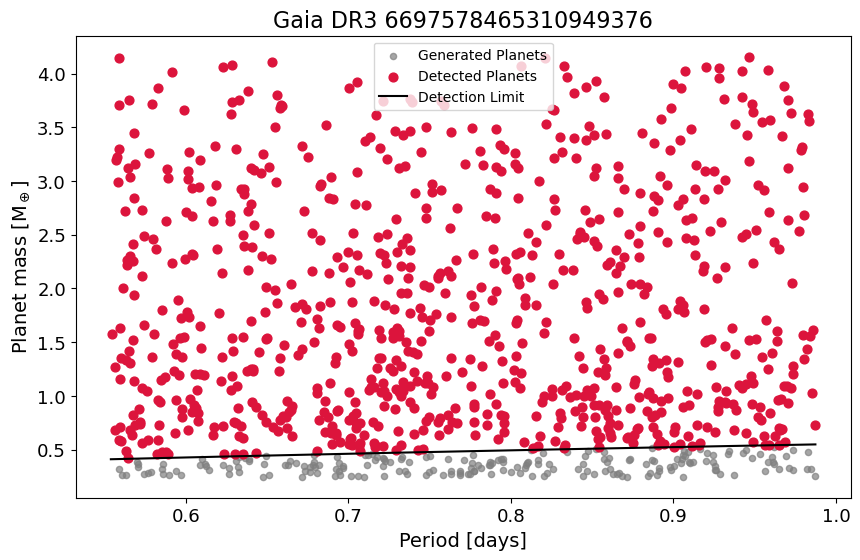

In [34]:
plot_one_star("Gaia DR3 6697578465310949376")

In [26]:
yield_estimation(output_path = "output/yield_results/MC10000_spawned_all_star_planets.csv",
                 mass_cutoff_mearth = [1, 1.25, 1.5, 1.75, 2, 2.25, 2.5],
                 mc_runs = 10000)

,source_id,HZ Detection Limit [M_Earth],HWO_match,LOPS2_match,TESS_confirmed_match,TESS_candidate_match,yield_1_mearth,yield_1.25_mearth,yield_1.5_mearth,yield_1.75_mearth,yield_2_mearth,yield_2.25_mearth,yield_2.5_mearth
0,Gaia DR3 5902750168276592256,0.878600,1,0,1,1,0.0010,0.0057,0.0124,0.0170,0.0215,0.0270,0.0305
1,Gaia DR3 4758877919212831104,0.499578,0,1,1,0,0.0182,0.0254,0.0338,0.0389,0.0435,0.0485,0.0531
2,Gaia DR3 6847167606385195648,0.500296,1,0,1,0,0.0153,0.0234,0.0298,0.0354,0.0419,0.0471,0.0521
3,Gaia DR3 2452378776434477184,0.552692,1,0,1,0,0.0141,0.0221,0.0288,0.0346,0.0411,0.0463,0.0506
4,Gaia DR3 4847957293278177024,0.604357,1,0,1,0,0.0091,0.0182,0.0253,0.0311,0.0374,0.0416,0.0461
...,...,...,...,...,...,...,...,...,...,...,...,...,...
777,Gaia DR2 4140792817780067200,1.986025,0,0,0,0,0.0000,0.0000,0.0000,0.0000,0.0000,0.0010,0.0038
778,Gaia DR3 2477891500647336704,1.989182,0,0,0,0,0.0000,0.0000,0.0000,0.0000,0.0000,0.0015,0.0034
779,Gaia DR2 6184678178105440512,1.990034,0,0,0,0,0.0000,0.0000,0.0000,0.0000,0.0000,0.0010,0.0038
780,Gaia DR3 3409686510941439104,1.991594,0,0,0,0,0.0000,0.0000,0.0000,0.0000,0.0000,0.0007,0.0028


In [27]:
yield_result = pd.read_csv("output/yield_results/MC10000_spawned_all_star_planets.csv")

source_ids = np.array(yield_result["source_id"].values)
HZ_detection_limits = np.array(yield_result["HZ Detection Limit [M_Earth]"].values)
yields_1_mearth = np.array(yield_result["yield_1_mearth"].values)
yields_1_25_mearth = np.array(yield_result["yield_1.25_mearth"].values)
yields_1_5_mearth = np.array(yield_result["yield_1.5_mearth"].values)
yields_1_75_mearth = np.array(yield_result["yield_1.75_mearth"].values)
yields_2_mearth = np.array(yield_result["yield_2_mearth"].values)
yields_2_25_mearth = np.array(yield_result["yield_2.25_mearth"].values)
yields_2_5_mearth = np.array(yield_result["yield_2.5_mearth"].values)
HWO_matches = np.array(yield_result["HWO_match"].values)
LOPS2_matches = np.array(yield_result["LOPS2_match"].values)
TESS_confirmed_matches = np.array(yield_result["TESS_confirmed_match"].values)
TESS_candidate_matches = np.array(yield_result["TESS_candidate_match"].values)

In [38]:
# Ranking of all stars based on HZ detection limit
sorted_indices = np.argsort(HZ_detection_limits)
all_source_ids_sorted = source_ids[sorted_indices]
all_stars_HZ_detection_limit_ranking = np.copy(all_source_ids_sorted)
for i, sid in enumerate(all_source_ids_sorted):
    print(f"Rank {i+1} | {sid} | HZ Detection Limit: {HZ_detection_limits[sorted_indices[i]]:.4f}")

Rank 1 | Gaia DR3 6697578465310949376 | HZ Detection Limit: 0.4109
Rank 2 | Gaia DR3 4911306239828325760 | HZ Detection Limit: 0.4399
Rank 3 | Gaia DR3 4911306239828325632 | HZ Detection Limit: 0.4487
Rank 4 | Gaia DR3 3487062064765702272 | HZ Detection Limit: 0.4498
Rank 5 | Gaia DR3 5412947081295024896 | HZ Detection Limit: 0.4614
Rank 6 | Gaia DR3 3478127463341507072 | HZ Detection Limit: 0.4697
Rank 7 | Gaia DR3 2552925644460225152 | HZ Detection Limit: 0.4699
Rank 8 | Gaia DR3 4364527594192166400 | HZ Detection Limit: 0.4706
Rank 9 | Gaia DR3 19316224572460416 | HZ Detection Limit: 0.4728
Rank 10 | Gaia DR3 3211461469444773376 | HZ Detection Limit: 0.4734
Rank 11 | Gaia DR3 5835113573101867520 | HZ Detection Limit: 0.4809
Rank 12 | Gaia DR3 5914096303621755520 | HZ Detection Limit: 0.4932
Rank 13 | Gaia DR3 4937000898856156288 | HZ Detection Limit: 0.4993
Rank 14 | Gaia DR3 4758877919212831104 | HZ Detection Limit: 0.4996
Rank 15 | Gaia DR3 6380214844952702848 | HZ Detection Limit

In [39]:
# Ranking of all stars based on their yield for planets with mass < 2 M_Earth
sorted_indices = np.flip(np.argsort(yields_2_mearth))
all_source_ids_sorted = source_ids[sorted_indices]
all_stars_yield_ranking = np.copy(all_source_ids_sorted)
for i, sid in enumerate(all_source_ids_sorted):
    print(f"Rank {i+1} | {sid} | Yield: {yields_2_mearth[sorted_indices[i]]:.4f}")

Rank 1 | Gaia DR3 6697578465310949376 | Yield: 0.0481
Rank 2 | Gaia DR3 4364527594192166400 | Yield: 0.0480
Rank 3 | Gaia DR3 3478127463341507072 | Yield: 0.0478
Rank 4 | Gaia DR3 3211461469444773376 | Yield: 0.0476
Rank 5 | Gaia DR3 2552925644460225152 | Yield: 0.0470
Rank 6 | Gaia DR3 4911306239828325632 | Yield: 0.0467
Rank 7 | Gaia DR3 5412947081295024896 | Yield: 0.0465
Rank 8 | Gaia DR3 5835113573101867520 | Yield: 0.0458
Rank 9 | Gaia DR3 5835498883232034816 | Yield: 0.0456
Rank 10 | Gaia DR2 4377160604838377600 | Yield: 0.0448
Rank 11 | Gaia DR3 5914096303621755520 | Yield: 0.0446
Rank 12 | Gaia DR3 4911306239828325760 | Yield: 0.0445
Rank 13 | Gaia DR3 3487062064765702272 | Yield: 0.0444
Rank 14 | Gaia DR3 4758877919212831104 | Yield: 0.0435
Rank 15 | Gaia DR3 19316224572460416 | Yield: 0.0428
Rank 16 | Gaia DR3 5951165616611763456 | Yield: 0.0426
Rank 17 | Gaia DR3 6380214844952702848 | Yield: 0.0423
Rank 18 | Gaia DR3 4937000898856156288 | Yield: 0.0423
Rank 19 | Gaia DR3 51

In [41]:
for i, sid in enumerate(all_stars_yield_ranking):
    if sid in all_stars_HZ_detection_limit_ranking:
        hz_rank = np.where(all_stars_HZ_detection_limit_ranking == sid)[0][0] + 1
        yield_rank = i + 1
        print(f"{sid} | HZ Detection Limit Rank: {hz_rank} | Yield Rank: {yield_rank}")

Gaia DR3 6697578465310949376 | HZ Detection Limit Rank: 1 | Yield Rank: 1
Gaia DR3 4364527594192166400 | HZ Detection Limit Rank: 8 | Yield Rank: 2
Gaia DR3 3478127463341507072 | HZ Detection Limit Rank: 6 | Yield Rank: 3
Gaia DR3 3211461469444773376 | HZ Detection Limit Rank: 10 | Yield Rank: 4
Gaia DR3 2552925644460225152 | HZ Detection Limit Rank: 7 | Yield Rank: 5
Gaia DR3 4911306239828325632 | HZ Detection Limit Rank: 3 | Yield Rank: 6
Gaia DR3 5412947081295024896 | HZ Detection Limit Rank: 5 | Yield Rank: 7
Gaia DR3 5835113573101867520 | HZ Detection Limit Rank: 11 | Yield Rank: 8
Gaia DR3 5835498883232034816 | HZ Detection Limit Rank: 24 | Yield Rank: 9
Gaia DR2 4377160604838377600 | HZ Detection Limit Rank: 18 | Yield Rank: 10
Gaia DR3 5914096303621755520 | HZ Detection Limit Rank: 12 | Yield Rank: 11
Gaia DR3 4911306239828325760 | HZ Detection Limit Rank: 2 | Yield Rank: 12
Gaia DR3 3487062064765702272 | HZ Detection Limit Rank: 4 | Yield Rank: 13
Gaia DR3 4758877919212831104 

In [33]:
# Ranking of HWO-cross matched stars (with HZ detection limit < 1) based on their yield for planets with mass < 2 M_Earth
HWO_matched_indices = np.where((HWO_matches == 1) & (HZ_detection_limits < 1))[0]
HWO_matched_yields = yields_2_mearth[HWO_matched_indices]
HWO_sorted_indices = np.flip(np.argsort(HWO_matched_yields))
HWO_sorted_source_ids = source_ids[HWO_matched_indices][HWO_sorted_indices]
for i, sid in enumerate(HWO_sorted_source_ids):
    print(f"Rank {i+1} | {sid} | Yield: {HWO_matched_yields[HWO_sorted_indices[i]]:.4f}")

Rank 1 | Gaia DR3 3211461469444773376 | Yield: 0.0476
Rank 2 | Gaia DR3 2552925644460225152 | Yield: 0.0470
Rank 3 | Gaia DR3 5640565607657897728 | Yield: 0.0419
Rank 4 | Gaia DR3 6847167606385195648 | Yield: 0.0419
Rank 5 | Gaia DR3 5117974602912370432 | Yield: 0.0414
Rank 6 | Gaia DR3 2452378776434477184 | Yield: 0.0411
Rank 7 | Gaia DR3 4847957293278177024 | Yield: 0.0374
Rank 8 | Gaia DR3 5726982995343100928 | Yield: 0.0334
Rank 9 | Gaia DR3 3507879565090229888 | Yield: 0.0317
Rank 10 | Gaia DR3 5381537023379295232 | Yield: 0.0315
Rank 11 | Gaia DR3 3023711269067191296 | Yield: 0.0284
Rank 12 | Gaia DR3 4345775217221821312 | Yield: 0.0263
Rank 13 | Gaia DR3 4900108950849461248 | Yield: 0.0255
Rank 14 | Gaia DR3 6427244702486210816 | Yield: 0.0249
Rank 15 | Gaia DR3 5902750168276592256 | Yield: 0.0215
Rank 16 | Gaia DR3 6427464123776727168 | Yield: 0.0207


In [35]:
# Ranking of LOPS2-cross matched stars (with HZ detection limit < 1) based on their yield for planets with mass < 2 M_Earth
LOPS2_matched_indices = np.where((LOPS2_matches == 1) & (HZ_detection_limits < 1))[0]
LOPS2_matched_yields = yields_2_mearth[LOPS2_matched_indices]
LOPS2_sorted_indices = np.flip(np.argsort(LOPS2_matched_yields))
LOPS2_sorted_source_ids = source_ids[LOPS2_matched_indices][LOPS2_sorted_indices]
for i, sid in enumerate(LOPS2_sorted_source_ids):
    print(f"Rank {i+1} | {sid} | Yield: {LOPS2_matched_yields[LOPS2_sorted_indices[i]]:.4f}")

Rank 1 | Gaia DR3 4758877919212831104 | Yield: 0.0435
Rank 2 | Gaia DR3 2904830113367963264 | Yield: 0.0421
Rank 3 | Gaia DR3 4780166972587269120 | Yield: 0.0415
Rank 4 | Gaia DR3 5593584059906793088 | Yield: 0.0392
Rank 5 | Gaia DR3 4866978844438656768 | Yield: 0.0377
Rank 6 | Gaia DR3 4784805056230587392 | Yield: 0.0341
Rank 7 | Gaia DR3 5559265690666327168 | Yield: 0.0334
Rank 8 | Gaia DR3 4657193606465368704 | Yield: 0.0304
Rank 9 | Gaia DR3 4764556724971292544 | Yield: 0.0275
Rank 10 | Gaia DR3 4777123623183866240 | Yield: 0.0255
Rank 11 | Gaia DR3 4777373903814124032 | Yield: 0.0247
Rank 12 | Gaia DR3 4866887138297037184 | Yield: 0.0240
Rank 13 | Gaia DR3 4796263719738968832 | Yield: 0.0239
Rank 14 | Gaia DR3 5493588665684618752 | Yield: 0.0235
Rank 15 | Gaia DR3 5485320853638354304 | Yield: 0.0230
Rank 16 | Gaia DR3 5505483938387762816 | Yield: 0.0225
Rank 17 | Gaia DR3 5488567574038257280 | Yield: 0.0223
Rank 18 | Gaia DR3 4775347916201249920 | Yield: 0.0210
Rank 19 | Gaia DR3 

In [36]:
# Ranking of TESS_confirmed-cross matched stars (with HZ detection limit < 1) based on their yield for planets with mass < 2 M_Earth
TESS_matched_indices = np.where((TESS_confirmed_matches == 1) & (HZ_detection_limits < 1))[0]
TESS_matched_yields = yields_2_mearth[TESS_matched_indices]
TESS_sorted_indices = np.flip(np.argsort(TESS_matched_yields))
TESS_sorted_source_ids = source_ids[TESS_matched_indices][TESS_sorted_indices]
for i, sid in enumerate(TESS_sorted_source_ids):
    print(f"Rank {i+1} | {sid} | Yield: {TESS_matched_yields[TESS_sorted_indices[i]]:.4f}")

Rank 1 | Gaia DR3 4758877919212831104 | Yield: 0.0435
Rank 2 | Gaia DR3 4937000898856156288 | Yield: 0.0423
Rank 3 | Gaia DR3 6380214844952702848 | Yield: 0.0423
Rank 4 | Gaia DR3 6847167606385195648 | Yield: 0.0419
Rank 5 | Gaia DR3 2452378776434477184 | Yield: 0.0411
Rank 6 | Gaia DR3 4847957293278177024 | Yield: 0.0374
Rank 7 | Gaia DR3 3812355294262255104 | Yield: 0.0353
Rank 8 | Gaia DR3 3494677900774838144 | Yield: 0.0345
Rank 9 | Gaia DR3 5726982995343100928 | Yield: 0.0334
Rank 10 | Gaia DR3 3684934540986187776 | Yield: 0.0327
Rank 11 | Gaia DR3 3507879565090229888 | Yield: 0.0317
Rank 12 | Gaia DR3 2623505219992303104 | Yield: 0.0315
Rank 13 | Gaia DR3 5381537023379295232 | Yield: 0.0315
Rank 14 | Gaia DR3 4657193606465368704 | Yield: 0.0304
Rank 15 | Gaia DR3 2966316109264052096 | Yield: 0.0300
Rank 16 | Gaia DR3 4383374219923745024 | Yield: 0.0293
Rank 17 | Gaia DR3 6718894388002453120 | Yield: 0.0291
Rank 18 | Gaia DR3 6029992663310612096 | Yield: 0.0282
Rank 19 | Gaia DR3 